### WS 2020/21 <span style="float: right;">GET Lab<br />Paderborn University</span><br />
## <center>Digital Image Processing I<br /><br />Task Sheet 11</center>
---

### Overview

The main objective of this exercise is to study highpass filters in the frequency domain, their application, and image restoration in the frequency domain. Furthermore, some relations between filtering in the spatial and in the frequency domain are considered. For the highpass filters, three types are studied: the ideal highpass filter (IHPF), the Butterworth highpass filter (BHPF), and the Gaussian highpass filter (GHPF).

If $H_{\text{LP}}(u,v)$ is the transfer function of the corresponding lowpass filter, the transfer functions can be computed as follows:

$$H_{\text{HP}}(u,v) = 1-H_{\text{LP}}(u,v)$$

The centered spatial representation of such filters can be computed as shown on task sheet 10. Furthermore, it follows:

$$h_{\text{HP}}(x,y) = \text{IDFT}\{H_{\text{HP}}(u,v)\} = \text{IDFT}\{1-H_{\text{LP}}(u,v)\} = \delta(x,y)-h_{\text{LP}}(x,y)$$

In this equation, $\delta(x,y)$ is the unit impulse in the spatial domain, which is an array with a $1$ in the center and $0$ everywhere else.

*Note*: All functions from task sheet 10 are imported here for reuse.

---

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
import time

dpi = plt.rcParams['figure.dpi']

# plot grayscale image in original size
def plot_img_orig(img):
    rows, cols = img.shape # image size
    fig = plt.figure(figsize = (cols/dpi, rows/dpi))
    fig.add_axes([0, 0, 1, 1])
    plt.axis('off')
    plt.imshow(img, cmap='gray', vmin=0, vmax=255)
    plt.show()

In [2]:
# based on the log transformation from task sheet 4
def log_transformation(img):
    # create empty image
    rows, cols = img.shape # image size
    res = np.zeros(shape=[rows, cols], dtype=np.float64) # init with zeros

    for iy in range(rows):
        for jx in range(cols):
            c = 255 / np.log(1 + np.amax(img)) # normalize result to 255*[0,1]
            res[iy, jx] = c * np.log(1 + img[iy, jx]) # min of log = 0, max = np.log(1 + img[i, j])
            
    # return result
    return res

In [3]:
# import all functions from task sheet 10
from exercise_10_solution import *

#### <span style="color: RoyalBlue; font-weight: bold;">Task 11.1</span> Highpass Filters

Implement / solve the following tasks:
    
1. For each filter type, create $200 \times 200$ highpass filters with $D_0 = 10, 20, 30$ (use $n=2$ for the BHPF), respectively.
2. Compute and plot the (normalized) spatial representations of these filters and compare the results.
3. Use the transfer functions with $D_0 = 20$ to filter some images (e.g., *checkerboard.png*, which has a size of $200 \times 200$ pixels) and compare the results.

*Note*: In the spatial domain, the filters have a peak at the center and relatively small values around. If these representations are normalized to the standard range $[0, 255]$ of gray values, only the peak becomes clearly visible. One way to deal with this is to normalize the result in the first step and to log transform it in the second step (because the log transformation requires positive values). Another method is to multiply the spatial representations by a large number (e.g., $10^5$) and to plot the result, which is automatically clipped then.

In [4]:
# compute spatial representation, normalize to [0,255], and apply log transformation
def spatial_norm_log(img):
    res = spatial_repr(img) #function imported from Ex-10
    res = cv2.normalize(res, None, 0, 255, cv2.NORM_MINMAX)
    res = log_transformation(res)
    return res

In [10]:
# IHPF
ihpf1 = 1-tf_ilpf(200, 200, 10) 
cv2.imwrite("output/ihpf1.png", 255*ihpf1)

True

In [11]:
ihpf2 = 1-tf_ilpf(200, 200, 20)
cv2.imwrite("output/ihpf2.png", 255*ihpf2)

True

In [12]:
ihpf3 = 1-tf_ilpf(200, 200, 30)
cv2.imwrite("output/ihpf3.png", 255*ihpf3)

True

In [13]:
# compute and plot the spatial representations
ihpf1_spatial_n_log = spatial_norm_log(ihpf1) 
cv2.imwrite("output/ihpf1_spatial_n.png", ihpf1_spatial_n_log)

True

In [14]:
ihpf2_spatial_n_log = spatial_norm_log(ihpf2) 
cv2.imwrite("output/ihpf2_spatial_n.png", ihpf2_spatial_n_log)

True

In [15]:
ihpf3_spatial_n_log = spatial_norm_log(ihpf3) 
cv2.imwrite("output/ihpf3_spatial_n.png", ihpf3_spatial_n_log)

True

In [16]:
# BHPF
bhpf1 = 1-tf_blpf(200, 200, 10, 2) 
cv2.imwrite("output/bhpf1.png", 255*bhpf1)

bhpf2 = 1-tf_blpf(200, 200, 20, 2) 
cv2.imwrite("output/bhpf2.png", 255*bhpf2)

bhpf3 = 1-tf_blpf(200, 200, 30, 2)
cv2.imwrite("output/bhpf3.png", 255*bhpf3)

True

In [17]:
# compute and plot the spatial representations
bhpf1_spatial_n_log = spatial_norm_log(bhpf1) 
cv2.imwrite("output/bhpf1_spatial_n.png", bhpf1_spatial_n_log)

bhpf2_spatial_n_log = spatial_norm_log(bhpf2) 
cv2.imwrite("output/bhpf2_spatial_n.png", bhpf2_spatial_n_log)

bhpf3_spatial_n_log = spatial_norm_log(bhpf3) 
cv2.imwrite("output/bhpf3_spatial_n.png", bhpf3_spatial_n_log)

True

In [18]:
# GHPF
ghpf1 = 1-tf_glpf(200, 200, 10) 
cv2.imwrite("output/ghpf1.png", 255*ghpf1)

ghpf2 = 1-tf_glpf(200, 200, 20) 
cv2.imwrite("output/ghpf2.png", 255*ghpf2)

ghpf3 = 1-tf_glpf(200, 200, 30) 
cv2.imwrite("output/ghpf3.png", 255*ghpf3)

True

In [19]:
# compute and plot the spatial representations
ghpf1_spatial_n_log = spatial_norm_log(ghpf1) 
cv2.imwrite("output/ghpf1_spatial_n.png", ghpf1_spatial_n_log)

ghpf2_spatial_n_log = spatial_norm_log(ghpf2)
cv2.imwrite("output/ghpf2_spatial_n.png", ghpf2_spatial_n_log)

ghpf3_spatial_n_log = spatial_norm_log(ghpf3) 
cv2.imwrite("output/ghpf3_spatial_n.png", ghpf3_spatial_n_log)

True

Spatial representations of an IHPF, BHPF, and GHPF, multiplied by 100 000 and clipped:


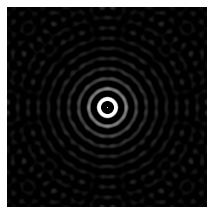

In [20]:
# example plots of clipped spatial representations (see task 8.1 for clipping)
print("Spatial representations of an IHPF, BHPF, and GHPF, multiplied by 100 000 and clipped:")
ihpf2_spatial = spatial_repr(ihpf2)
plot_img_orig(100000*ihpf2_spatial)

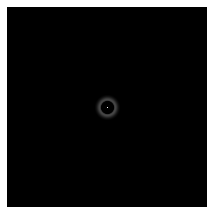

In [21]:
bhpf2_spatial = spatial_repr(bhpf2) 
plot_img_orig(100000*bhpf2_spatial)

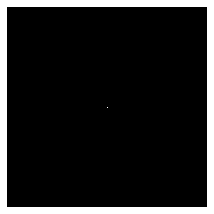

In [22]:
ghpf2_spatial = spatial_repr(ghpf2) 
plot_img_orig(100000*ghpf2_spatial)

In [23]:
# read the image as a grayscale image (parameter 0)
img = cv2.imread('images/checkerboard.png', 0)

IHPF:


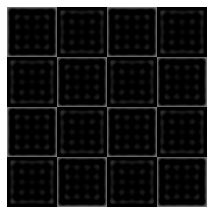

In [24]:
# application
print("IHPF:") 
ihpf2_res = filter_img(img, ihpf2) #function filter_img imported from Ex-10
plot_img_orig(ihpf2_res)

BHPF:


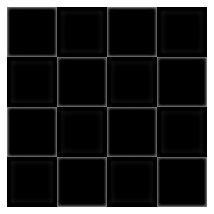

In [25]:
print("BHPF:"); 
bhpf2_res = filter_img(img, bhpf2); 
plot_img_orig(bhpf2_res)

GHPF:


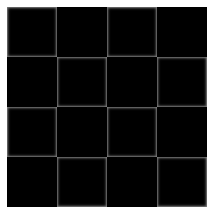

In [27]:
print("GHPF:"); 
ghpf2_res = filter_img(img, ghpf2); 
plot_img_orig(ghpf2_res)

<table align="left">
<tr>
    <td>IHPF: $H(u,v)$</td>
    <td>$h(x,y)$</td>
</tr>
<tr>
    <td><img src="output/ihpf1.png"></td>
    <td><img src="output/ihpf1_spatial_n.png"></td>
</tr>
<tr>
    <td><img src="output/ihpf2.png"></td>
    <td><img src="output/ihpf2_spatial_n.png"></td>
</tr>
<tr>
    <td><img src="output/ihpf3.png"></td>
    <td><img src="output/ihpf3_spatial_n.png"></td>
</tr>
<tr>
    <td>BHPF: $H(u,v)$</td>
    <td>$h(x,y)$</td>
</tr>
<tr>
    <td><img src="output/bhpf1.png"></td>
    <td><img src="output/bhpf1_spatial_n.png"></td>
</tr>
<tr>
    <td><img src="output/bhpf2.png"></td>
    <td><img src="output/bhpf2_spatial_n.png"></td>
</tr>
<tr>
    <td><img src="output/bhpf3.png"></td>
    <td><img src="output/bhpf3_spatial_n.png"></td>
</tr>

<tr>
    <td>GHPF: $H(u,v)$</td>
    <td>$h(x,y)$</td>
</tr>
<tr>
    <td><img src="output/ghpf1.png"></td>
    <td><img src="output/ghpf1_spatial_n.png"></td>
</tr>
<tr>
    <td><img src="output/ghpf2.png"></td>
    <td><img src="output/ghpf2_spatial_n.png"></td>
</tr>
<tr>
    <td><img src="output/ghpf3.png"></td>
    <td><img src="output/ghpf3_spatial_n.png"></td>
</tr>
</table>

The results show that highpass filtering can be used for edge detection. The principal behaviour of the filters is compareable to their corresponding lowpass filters. In particular, the IHPF leads to ringing, while the BHPF and GHPF lead to smooth results. This would also be the case for the BHPF for higher orders (for example, $n=10$). The unit impulse in the center (see overview) is clearly visible. Furthermore, the inverse relationship between the filter size in the spatial and frequency domain becomes apparent.

#### <span style="color: RoyalBlue; font-weight: bold;">Task 11.2</span> Image Restoration

An important application of image processing in the frequency domain is image enhancement and restoration. In particular, unwanted regular patterns can be directly identified and removed in the frequency domain by setting the values of the Fourier transform to zero at the corresponding frequencies. In other words, it can be much simpler to specify a filter in the frequency domain than in the spatial domain (this can also apply vice versa).

Implement / solve the following tasks:
    
1. Read the image *restoration1.png* as a grayscale image and plot it.
2. Compute and plot (save) the log transformed spectrum of this image.
3. Identify the periodic pattern in the image and create a filter in the frequency domain to remove the pattern (e.g., use an image editor such as <a href="https://www.gimp.org/">`GIMP` ↗</a>).
4. Compute the corresponding IDFT and plot the enhanced (normalized) image.
5. Repeat this procedure for the image *restoration2.png*.

Input image:


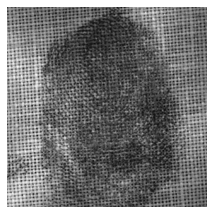

In [28]:
# read the image as a grayscale image (parameter 0)
print("Input image:")
img1 = cv2.imread('images/restoration1.png', 0)
plot_img_orig(img1)

In [29]:
# compute DFT and spectrum
img1_dft = np.fft.fft2(img1) # compute DFT (no normalization to 1/MN)
img1_dft_shift = np.fft.fftshift(img1_dft) # shift FFT to the center
img1_spec_shift = np.absolute(img1_dft_shift)

Spectrum:


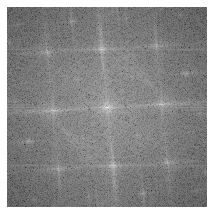

True

In [30]:
# plot and save the log-normalized spectrum
print("Spectrum:")
img1_spec_shift_log = log_transformation(img1_spec_shift)
plot_img_orig(img1_spec_shift_log)
cv2.imwrite("output/spectrum1.png", img1_spec_shift_log)

Mask:


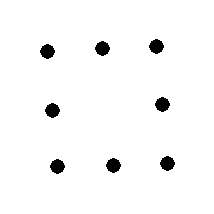

Masked spectrum:


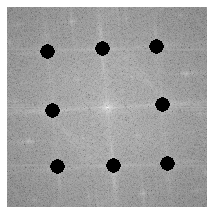

In [32]:
# multiply Fourier transform by mask
mask1 = cv2.imread('images/mask1.png', 0)
#mask1 = 255-mask1 # invert mask (can be used to check identified pattern)
print("Mask:")
plot_img_orig(mask1)
img1_dft_shift_res = np.multiply(mask1, img1_dft_shift)
print("Masked spectrum:")
plot_img_orig(log_transformation(np.absolute(img1_dft_shift_res)))

Result after IDFT (normalized):


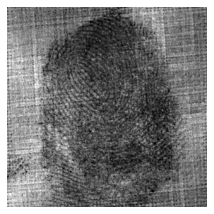

In [33]:
# inverse DFT (IDFT)
img1_dft_backshift = np.fft.ifftshift(img1_dft_shift_res) # shift centered FFT back to top left
img1_idft = np.fft.ifft2(img1_dft_backshift) # compute IDFT
img1_back = np.real(img1_idft) # take only real part, as all imaginary parts are parasitic
img1_back_n = cv2.normalize(img1_back, None, 0, 255, cv2.NORM_MINMAX)
print("Result after IDFT (normalized):")
plot_img_orig(img1_back_n)

# note: the remaining code is only copy and paste of the previous code to see all examples directly

Input image:


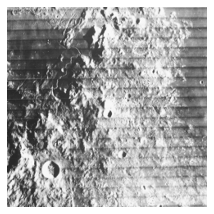

In [34]:
# read the image as a grayscale image (parameter 0)
img2 = cv2.imread('images/restoration2.png', 0)
print("Input image:")
plot_img_orig(img2)

In [35]:
# compute DFT and spectrum
img2_dft = np.fft.fft2(img2) # compute DFT (no normalization to 1/MN)
img2_dft_shift = np.fft.fftshift(img2_dft) # shift FFT to the center
img2_spec_shift = np.absolute(img2_dft_shift)

Spectrum:


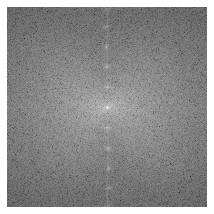

True

In [36]:
# plot and save the log-normalized spectrum
print("Spectrum:")
img2_spec_shift_log = log_transformation(img2_spec_shift)
plot_img_orig(img2_spec_shift_log)
cv2.imwrite("output/spectrum2.png", img2_spec_shift_log)

Mask:


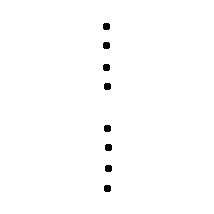

Masked spectrum:


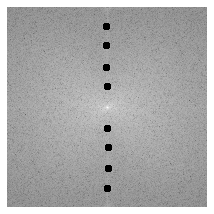

In [37]:
# multiply Fourier transform by mask
mask2 = cv2.imread('images/mask2.png', 0)
#mask2 = 255-mask2 # invert mask (can be used to check identified pattern)
print("Mask:")
plot_img_orig(mask2)
img2_dft_shift_res = np.multiply(mask2, img2_dft_shift)
print("Masked spectrum:")
plot_img_orig(log_transformation(np.absolute(img2_dft_shift_res)))

Result after IDFT (normalized):


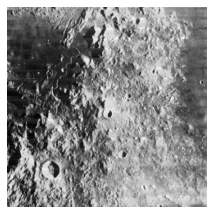

In [38]:
# inverse DFT (IDFT)
img2_dft_backshift = np.fft.ifftshift(img2_dft_shift_res) # shift centered FFT back to top left
img2_idft = np.fft.ifft2(img2_dft_backshift) # compute IDFT
img2_back = np.real(img2_idft) # take only real part, as all imaginary parts are parasitic
img2_back_n = cv2.normalize(img2_back, None, 0, 255, cv2.NORM_MINMAX)
print("Result after IDFT (normalized):")
plot_img_orig(img2_back_n)

*Note*: Such a filtering process can also be automated, for example by thresholding the spectrum and searching for peaks, which can then be removed.

#### <span style="color: RoyalBlue; font-weight: bold;">Task 11.3</span> Spatial Filters in the Frequency Domain

As already discussed, multiplication in the frequency domain corresponds to convolution in the spatial domain. One application of filtering in the spatial domain is edge detection, for which the Sobel operator can be used. The objective of this task is to obtain a frequency domain transfer function from a spatial kernel and to compare the filtering results. For this purpose, consider the following Sobel mask:

<br />
<center><img src="images/sobel.png" /></center>
<br />

Assume that the input image is *p-bulding-small2.png*, which has a size of $200 \times 200$ pixels. For an image $f(x,y)$ and a filter mask $h(x,y)$ of sizes $A \times B$ and $C \times D$, respectively, wraparound errors are avoided by choosing $P \geq A+C-1$ and $Q \geq B+D-1$, where $P \times Q$ is the size of the zero padded versions of $f(x,y)$ and $h(x,y)$ (see lecture notes for details). As a result, $P \times Q$ can be chosen $202 \times 202$ pixels.

Implement / solve the following tasks:
    
1. Compute the transfer function of the given Sobel mask and plot the (normalized) spectrum. For this purpose, it can be helpful to add a leading row and column of zeros to get a $4\times 4$ array which can then be centered in the zero padded version of the mask. 
2. Use this transfer function to filter the image *p-building-small2.png* and plot the result.
3. Implement the corresponding convolution in the spatial domain and plot the result.
4. Compare the results.

*Note*: For the convolution in the spatial domain, the OpenCV function <a href="https://docs.opencv.org/4.2.0/d4/d86/group__imgproc__filter.html#ga27c049795ce870216ddfb366086b5a04">`filter2D` ↗</a> can be used.

Input image:


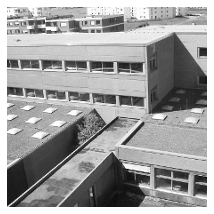

In [39]:
# read the image as a grayscale image (parameter 0)
img = cv2.imread('images/p-building-small2.png', 0)
print("Input image:")
plot_img_orig(img)

Padded input image:


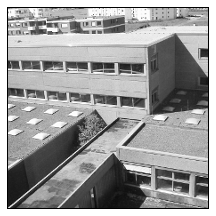

In [40]:
# zero padding of image
img_pad = cv2.copyMakeBorder(img, 1, 1, 1, 1, cv2.BORDER_CONSTANT) # top, bottom, left, right
print("Padded input image:")
plot_img_orig(img_pad)

In [41]:
# DFT of the image
img_dft = np.fft.fft2(img_pad)

In [42]:
# definition of the mask with odd symmetry
mask = np.array([[0, 0, 0, 0], [0, -1, 0, 1], [0, -2, 0, 2], [0, -1, 0, 1]]) # from task 8 with additional zeros
print("Mask:")
print(mask)

Mask:
[[ 0  0  0  0]
 [ 0 -1  0  1]
 [ 0 -2  0  2]
 [ 0 -1  0  1]]


In [43]:
# zero padding of the mask (cv2.copyMakeBorder does not work for negative values)
mask_pad = np.zeros(shape=[202, 202], dtype=np.float64)
mask_pad[99:103,99:103] = mask # mask is centered now
print(mask_pad)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


Mask in the frequency domain:


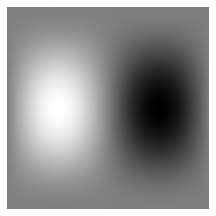

In [44]:
# DFT and plot of the spectrum (only imaginary parts if mask is real and odd)
mask_pad_backshift = np.fft.ifftshift(mask_pad) # backshift centered mask
mask_pad_backshift_dft = np.fft.fft2(mask_pad_backshift) # compute DFT
mask_pad_dft = np.fft.fftshift(mask_pad_backshift_dft) # center the DFT
mask_pad_dft_imag = np.imag(mask_pad_dft)
mask_pad_dft_imag_n = cv2.normalize(mask_pad_dft_imag, None, 0, 255, cv2.NORM_MINMAX)
print("Mask in the frequency domain:")
plot_img_orig(mask_pad_dft_imag_n)

Multiplication in the frequency domain:


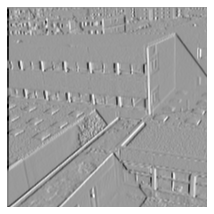

In [45]:
# filtering in the frequency domain
res_dft = np.multiply(img_dft, mask_pad_backshift_dft) # both transfer functions are not shifted

# IDFT
res_idft = np.fft.ifft2(res_dft)
res_final = np.real(res_idft)
res_final_crop = res_final[0:200,0:200]
res_final_n = cv2.normalize(res_final_crop, None, 0, 255, cv2.NORM_MINMAX)
print("Multiplication in the frequency domain:")
plot_img_orig(res_final_n)

In [46]:
# direct convolution in the spatial domain
mask_flipped = cv2.flip(mask, -1)
print("Flipped mask:")
print(mask_flipped)

Flipped mask:
[[ 1  0 -1  0]
 [ 2  0 -2  0]
 [ 1  0 -1  0]
 [ 0  0  0  0]]


Direct convolution in the spatial domain:


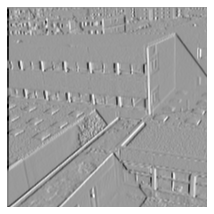

In [47]:
res_sobel = cv2.filter2D(img, cv2.CV_64F, mask_flipped, borderType=cv2.BORDER_CONSTANT)
res_sobel_n = cv2.normalize(res_sobel, None, 0, 255, cv2.NORM_MINMAX)
print("Direct convolution in the spatial domain:")
plot_img_orig(res_sobel_n)

As can be seen, the Sobel mask in the frequency domain emphasizes (and demphasizes) specific positive and negative frequencies, which directly correspond to horizontal edges. 

#### <span style="color: RoyalBlue; font-weight: bold;">Task 11.4</span> Template Matching (Correlation) in the Frequency Domain

The objective of this task is to compare correlation in the spatial and in the frequency domain and to use it for template matching (finding a given template or pattern in an image). Spatial filtering as discussed before is - from a mathematical point of view - a correlation. A correlation leads to the highest values if the functions (image and template) are similiar or identical. It can then be assumed that the pattern has been found at these positions. In principle, correlation and convolution lead to the same results if the filter mask is rotated (flipped) by 180 degrees.

Implement / solve the following tasks:
    
1. Implement the correlation in the spatial domain to find the letter *R* in the image *upb-logo.png*. Use *upb-logo-r.png* as the template.
2. Plot the (normalized) correlation result.
3. Implement the correlation in the frequency domain and plot the result.
4. Compare the results.

*Note*: For the correlation in the spatial domain, the OpenCV function <a href="https://docs.opencv.org/4.2.0/d4/d86/group__imgproc__filter.html#ga27c049795ce870216ddfb366086b5a04">`filter2D` ↗</a> can be used.

Input image:


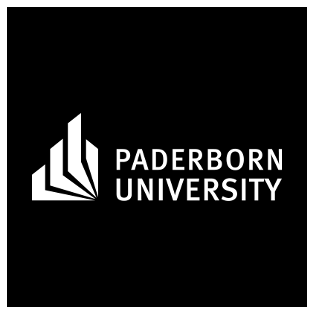

In [73]:
# read the image as a grayscale image (parameter 0)
img = cv2.imread('images/upb-logo.png', 0)
print("Input image:")
plot_img_orig(img)

Padded input image:


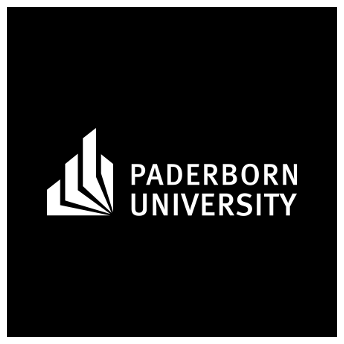

In [74]:
# zero padding of the image
img_pad = cv2.copyMakeBorder(img, 15, 15, 15, 15, cv2.BORDER_CONSTANT) # top, bottom, left, right
print("Padded input image:")
plot_img_orig(img_pad)

Template:


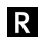

In [75]:
# read template as a grayscale image (parameter 0)
template = cv2.imread('images/upb-logo-r.png', 0)
print("Template:")
plot_img_orig(template)

Padded template:


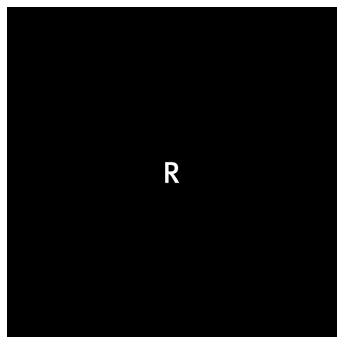

In [76]:
# zero padding of the template
template_pad = cv2.copyMakeBorder(template, 150, 150, 150, 150, cv2.BORDER_CONSTANT) # top, bottom, left, right
print("Padded template:")
plot_img_orig(template_pad)

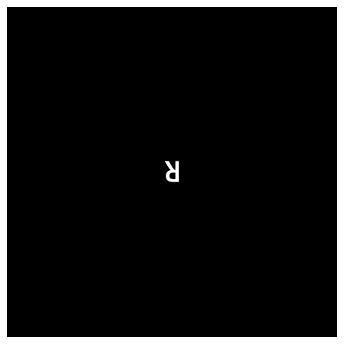

In [77]:
# rotate template by 180 deg for correlation in the frequency domain
template_pad_flipped = cv2.flip(template_pad, -1) 
plot_img_orig(template_pad_flipped)

In [78]:
# compute DFTs
img_dft = np.fft.fft2(img_pad)
template_pad_flipped_backshift = np.fft.ifftshift(template_pad_flipped) # backshift centered mask
template_dft = np.fft.fft2(template_pad_flipped_backshift)

In [79]:
# multiplication in the frequency domain
res = np.multiply(img_dft, template_dft)

Correlation result in the frequency domain (normalized):


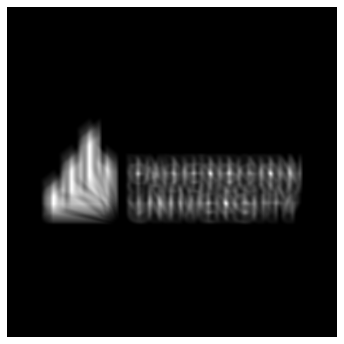

In [80]:
# IDFT and plot
res_idft = np.fft.ifft2(res)
res_final = np.real(res_idft)
res_final_n = cv2.normalize(res_final, None, 0, 255, cv2.NORM_MINMAX)
print("Correlation result in the frequency domain (normalized):")
plot_img_orig(res_final_n)

Correlation result in the spatial domain (normalized):


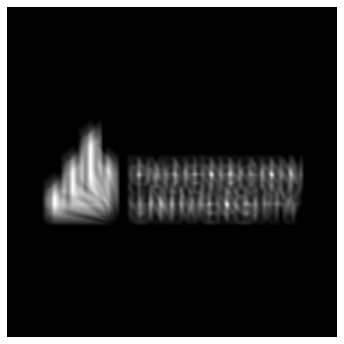

In [81]:
# direct correlation in the spatial domain
res_direct = cv2.filter2D(img_pad, cv2.CV_64F, template, borderType=cv2.BORDER_CONSTANT)
res_direct_n = cv2.normalize(res_direct, None, 0, 255, cv2.NORM_MINMAX)
print("Correlation result in the spatial domain (normalized):")
plot_img_orig(res_direct_n)

As one can see, the results are identical.